#Fashion 데이터 이미지 분류 모델

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
import matplotlib.pyplot as plt

# 데이터셋 로드 및 전처리
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

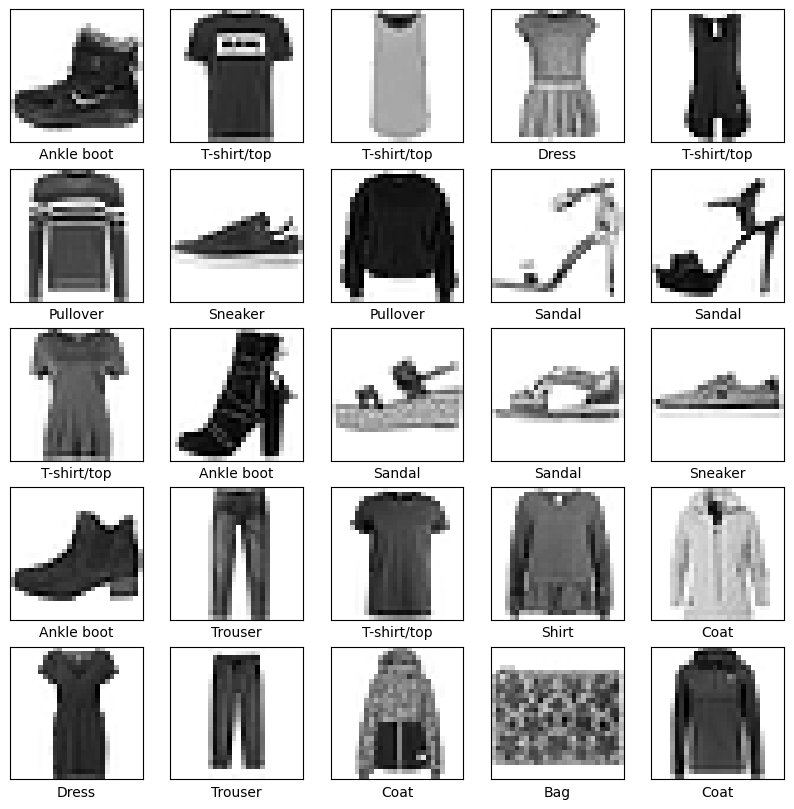

In [ ]:
# 클래스 이름 정의
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 이미지 시각화 함수
def plot_images(images, labels, class_names, num_images=25):
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[labels[i]])
    plt.show()

# 훈련 데이터셋의 25개 이미지 시각화
plot_images(train_images, train_labels, class_names)


In [ ]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), input_shape = (28,28,1), activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(10, activation='softmax')) ## 분류문제의 마지막 activation은 항상 softmax ##
model.summary()

# 모델 컴파일
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 모델 학습
model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 12, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 12, 12, 64)        0         
                                                                 
 flatten (Flatten)           (None, 9216)              0         
                                                                 
 dense (Dense)               (None, 10)                92170     
                                                      

/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5727: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 [==============================] - 182s 97ms/step - loss: 0.4057 - accuracy: 0.8567 - val_loss: 0.3263 - val_accuracy: 0.8859
Epoch 2/10
1875/1875 [==============================] - 176s 94ms/step - loss: 0.2790 - accuracy: 0.8999 - val_loss: 0.2751 - val_accuracy: 0.9007
Epoch 3/10
1875/1875 [==============================] - 174s 93ms/step - loss: 0.2393 - accuracy: 0.9135 - val_loss: 0.2694 - val_accuracy: 0.9009
Epoch 4/10
1875/1875 [==============================] - 177s 94ms/step - loss: 0.2104 - accuracy: 0.9243 - val_loss: 0.2481 - val_accuracy: 0.9121
Epoch 5/10
1875/1875 [==============================] - 177s 95ms/step - loss: 0.1898 - accuracy: 0.9301 - val_loss: 0.2501 - val_accuracy: 0.9116
Epoch 6/10
1875/1875 [==============================] - 174s 93ms/step - loss: 0.1714 - accuracy: 0.9371 - val_loss: 0.2424 - val_accuracy: 0.9154
Epoch 7/10
1875/1875 [==============================] - 176s 94ms/step - loss: 0.1592 - accuracy: 0.9413 - val_loss: 0.2377 - val

In [ ]:
# 모델 평가
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\n테스트 정확도:', test_acc)

# 예측 수행
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(test_images)

# 첫 번째 이미지 예측 결과 확인
print(predictions[0])
print("예측된 레이블:", predictions[0].argmax())
print("실제 레이블:", test_labels[0])

313/313 - 13s - loss: 0.2462 - accuracy: 0.9197 - 13s/epoch - 42ms/step

테스트 정확도: 0.919700026512146
313/313 [==============================] - 7s 23ms/step
[0.08533785 0.08533785 0.08533785 0.08533785 0.08533785 0.08534511
 0.08533785 0.08533809 0.08533785 0.23195186]
예측된 레이블: 9
실제 레이블: 9


# Cifar10 데이터를 이용한 이미지 분류 모델

In [12]:
# 사용할 라이브러리 불러오기
import numpy as np
#from keras.utils import np_utils
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Activation, Conv2D, MaxPooling2D, Flatten
from keras.utils import to_categorical
import matplotlib.pyplot as plt

In [13]:
# CIFAR-10 Dataset 가져오기
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print('x_train :', np.shape(x_train))
print('y_train :', np.shape(y_train))
print('x_test :', np.shape(x_test))
print('y_test :', np.shape(y_test))

170498071/170498071 [==============================] - 2s 0us/step
x_train : (50000, 32, 32, 3)
y_train : (50000, 1)
x_test : (10000, 32, 32, 3)
y_test : (10000, 1)


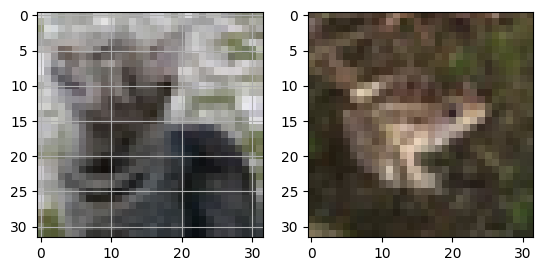

In [14]:
# 이미지 예제 시각화
plt.subplot(121)
plt.imshow(x_train[333])
plt.grid(True)
plt.subplot(122)
plt.imshow(x_train[22])
plt.grid(False)
plt.show()

In [15]:
# 데이터 스케일링
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 라벨 One-Hot Encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print('x_train :', np.shape(x_train))
print('y_train :', np.shape(y_train))

x_train : (50000, 32, 32, 3)
y_train : (50000, 10)


In [16]:
# 모델 구성하기
width = 32
height = 32
channel = 3
# 순차적 모델을 만들기 위한 Sequential() 함수
model = Sequential()
# filters : Kernel 그룹의 갯수 / kernel_size : Kernel 크기
model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu',
                 input_shape=(width, height, channel)))
# pool_size : MaxPooling 의 Window size
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
# N차원 배열을 1차원으로 펴줍니다
model.add(Flatten())
# 출력층 MLP
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 4, 4, 128)        

In [ ]:
# 모델 구성 및 학습
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x_train, y_train,epochs=3,batch_size=64,validation_data=(x_test, y_test))

##history는 결과를 저장하는 객체##

Epoch 1/3
782/782 [==============================] - 115s 145ms/step - loss: 1.1827 - accuracy: 0.5851 - val_loss: 1.0166 - val_accuracy: 0.6454
Epoch 2/3
782/782 [==============================] - 108s 138ms/step - loss: 0.9538 - accuracy: 0.6672 - val_loss: 0.9216 - val_accuracy: 0.6788
Epoch 3/3
782/782 [==============================] - 107s 137ms/step - loss: 0.8348 - accuracy: 0.7119 - val_loss: 0.8522 - val_accuracy: 0.7047


In [ ]:
#모델 평가
loss,acc = model.evaluate(x_test, y_test, batch_size=32)
print('Test set Loss and Accuracy')
print(loss)
print(acc)

313/313 [==============================] - 8s 25ms/step - loss: 0.8522 - accuracy: 0.7047
Test set Loss and Accuracy
0.8522202968597412
0.7046999931335449


1/1 [==============================] - 0s 167ms/step
예측: 개구리 / 정답: 고양이


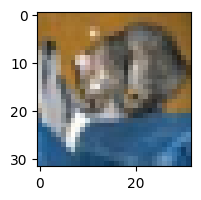

1/1 [==============================] - 0s 22ms/step
예측: 자동차 / 정답: 배


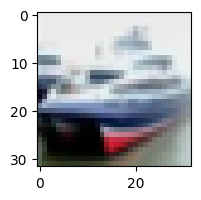

1/1 [==============================] - 0s 23ms/step
예측: 자동차 / 정답: 배


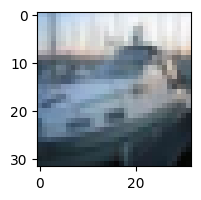

1/1 [==============================] - 0s 24ms/step
예측: 비행기 / 정답: 비행기


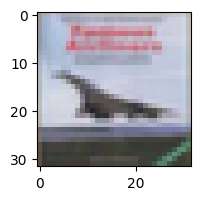

1/1 [==============================] - 0s 22ms/step
예측: 개구리 / 정답: 개구리


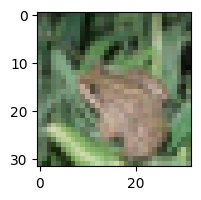

1/1 [==============================] - 0s 22ms/step
예측: 개구리 / 정답: 개구리


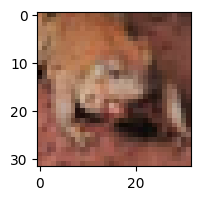

1/1 [==============================] - 0s 21ms/step
예측: 자동차 / 정답: 자동차


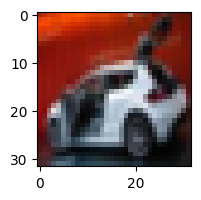

1/1 [==============================] - 0s 27ms/step
예측: 개구리 / 정답: 개구리


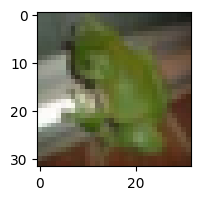

1/1 [==============================] - 0s 22ms/step
예측: 자동차 / 정답: 고양이


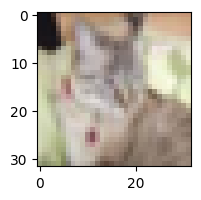

1/1 [==============================] - 0s 21ms/step
예측: 자동차 / 정답: 자동차


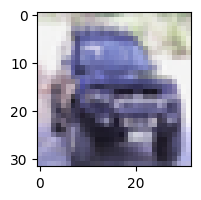

In [ ]:
labels = ['비행기', '자동차', '새', '고양이', '사슴', '개', '개구리', '말', '배', '트럭']
# 출력 그림의 크기를 결정합니다.
plt.rcParams["figure.figsize"] = (2,2)
for i in range(10):
  # 모델 사용
  output = model.predict(x_test[i].reshape(1,width, height, channel))

  # 이미지 출력
  plt.imshow(x_test[i].reshape(width, height, channel))
  # np.argmax()가 labels의 인덱스가 되어 labels 배열에 있는 문자열을 출력합니다.
  print('예측: ' + labels[np.argmax(output)] + ' / 정답: ' + labels[np.argmax(y_test[i])])
  plt.show()

# Flowers 데이터셋 예측

모듈 Import 및 데이터 전처리

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

# 데이터셋 로드
(dataset_train, dataset_test), dataset_info = tfds.load(
    'oxford_flowers102',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True
)

# 데이터 전처리 함수
def format_example(image, label):
    image = tf.image.resize(image, (150, 150))
    image = image / 255.0
    return image, label

# 데이터셋 전처리
train_batches = dataset_train.map(format_example).batch(32).prefetch(1)
test_batches = dataset_test.map(format_example).batch(32).prefetch(1)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/1020 [00:00<?, ? examples/s]

...

Generating test examples...:   0%|          | 0/6149 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.D5W1V1_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...:   0%|          | 0/1020 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.D5W1V1_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.


데이터 시각화

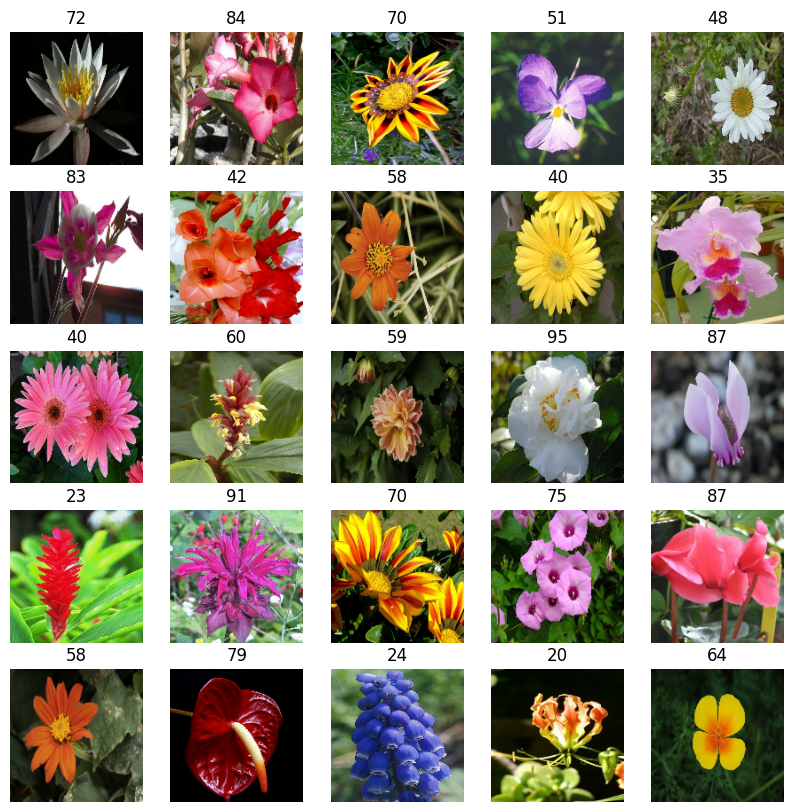

In [ ]:
def display_images(dataset, num_images):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(num_images):
            ax = plt.subplot(5, 5, i + 1)
            plt.imshow(images[i])
            plt.title(int(labels[i]))
            plt.axis("off")

# 훈련 데이터셋에서 25개의 이미지 시각화
display_images(train_batches, 25)


모델 구성

In [18]:
from tensorflow.keras import layers, models

# 모델 구성
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(102, activation='softmax')
])
model.summary()
# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 74, 74, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 36, 36, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 17, 17, 128)      

Epoch 1/3
32/32 [==============================] - 201s 6s/step - loss: 4.6155 - accuracy: 0.0088 - val_loss: 4.4398 - val_accuracy: 0.0146
Epoch 2/3
32/32 [==============================] - 191s 6s/step - loss: 4.3858 - accuracy: 0.0206 - val_loss: 4.2339 - val_accuracy: 0.0306
Epoch 3/3
32/32 [==============================] - 140s 4s/step - loss: 4.1480 - accuracy: 0.0412 - val_loss: 4.1002 - val_accuracy: 0.0581


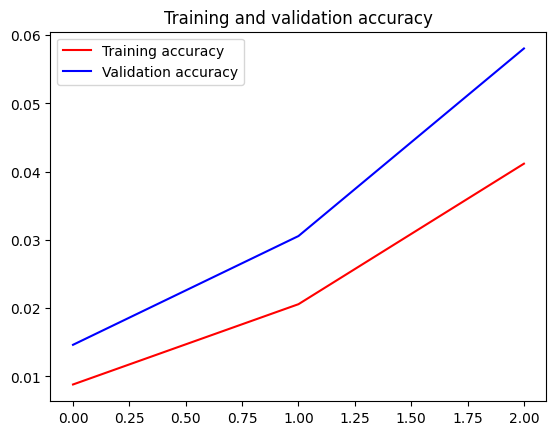

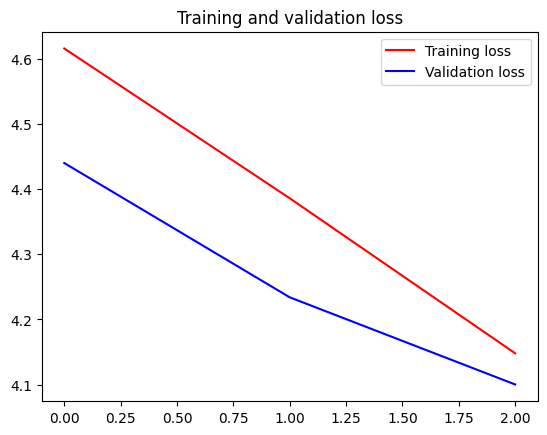

In [ ]:
# 모델 학습
history = model.fit(
    train_batches,
    epochs=3,
    validation_data=test_batches
)

# 모델 평가
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

import matplotlib.pyplot as plt

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.show()

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
